# 02 · Power simulation

This notebook checks whether production growth shows up in later announcement counts, and how many dated events we need to detect it.

Read-only: it reads `data/processed/` and `data/manual/` and writes nothing.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

DATA = Path("data") if Path("data").exists() else Path("../data")
SIMS = 3000
ALPHA = 0.05
LAGS = range(1, 7)
K_TRUE = 3

## 1. Load X (production growth) and Y (dated announcements)

In [ ]:
prod = pd.read_csv(DATA / "processed/ev_production_model_monthly.csv", parse_dates=["month"])
seg  = pd.read_csv(DATA / "processed/ev_registrations_segment_monthly.csv", parse_dates=["month"])
ann  = pd.read_csv(DATA / "manual/investment_announcements.csv")

production = prod.groupby("month")["production_units"].sum()
production = production[production.index <= "2026-07-01"]
registrations = seg.groupby("month")["ev_registrations"].sum()
registrations = registrations[registrations.index <= "2026-08-01"]

dated = ann[ann["date_precision"].isin(["exact", "month"])].copy()
dated["month"] = pd.to_datetime(dated["announcement_date"].str[:7] + "-01")
counts = dated.groupby("month").size()

growth = production.pct_change().dropna()
print("production growth months:", len(growth))
print("largest month:", growth.idxmax().date(), f"{growth.max():+.0%}")

production growth months: 39
largest month: 2023-05-01 +106%


The early production growth value is unusually large and may be a coverage issue. I clip X at ±2 SD before standardising it. Otherwise the simulation gives noticeably higher power.

In [ ]:
def standardise(series, clip=2.0):
    z = (series - series.mean()) / series.std()
    z = z.clip(-clip, clip)
    return ((z - z.mean()) / z.std()).values

x_prod = standardise(growth)
x_reg  = standardise(registrations.pct_change().dropna())
print(len(x_prod), "months of production X;", len(x_reg), "months of registration X")

39 months of production X; 103 months of registration X


## 2. Model setup and simulation

We use a Poisson regression for monthly announcement counts, with lagged production growth as the main variable and a time trend as the baseline.

There are two cases:
- lag fixed at k=3
- scan lags k=1..6 with Bonferroni correction

We call a simulation a detection when the estimated effect is positive and statistically significant. The batch solver below is checked against `statsmodels`.

In [ ]:
def design(x, k, n):
    t = np.arange(k, n)
    trend = (t - t.mean()) / n
    return np.column_stack([np.ones_like(trend), trend, x[t - k]]), t


def poisson_fit_batch(X, Y, iters=30):
    S, p = Y.shape[0], X.shape[1]
    B = np.zeros((S, p))
    B[:, 0] = np.log(np.maximum(Y.mean(axis=1), 1e-3))
    for _ in range(iters):
        mu = np.exp(np.clip(B @ X.T, -30, 30))
        H = np.einsum("sn,ni,nj->sij", mu, X, X) + np.eye(p) * 1e-9
        step = np.linalg.solve(H, ((Y - mu) @ X)[..., None])[..., 0]
        B += step
        if np.max(np.abs(step)) < 1e-8:
            break
    mu = np.exp(np.clip(B @ X.T, -30, 30))
    H = np.einsum("sn,ni,nj->sij", mu, X, X) + np.eye(p) * 1e-9
    se = np.sqrt(np.einsum("sii->si", np.linalg.inv(H)))
    ok = (Y.sum(axis=1) > 0) & np.isfinite(B).all(axis=1) & (np.abs(B[:, -1]) < 20)
    return B, se, ok


def simulate_power(x, total_events, rr, k_true=K_TRUE, trend_ratio=2.0, sims=SIMS, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    t = np.arange(n)
    lin = np.log(trend_ratio) * t / (n - 1)
    lin = lin + np.where(t >= k_true, np.log(rr) * x[np.clip(t - k_true, 0, None)], 0.0)
    mu = total_events / np.exp(lin).sum() * np.exp(lin)
    Y = rng.poisson(mu, size=(sims, n))

    def detect(k, alpha):
        Xd, rows = design(x, k, n)
        B, se, ok = poisson_fit_batch(Xd, Y[:, rows])
        return ok & (B[:, -1] / se[:, -1] > stats.norm.ppf(1 - alpha / 2))

    known = detect(k_true, ALPHA).mean()
    scan = np.zeros(sims, dtype=bool)
    for k in LAGS:
        scan |= detect(k, ALPHA / len(LAGS))
    return known, scan.mean()

In [ ]:
rng = np.random.default_rng(1)
Ycheck = rng.poisson(0.4, size=(3, len(x_prod)))
Xd, rows = design(x_prod, 3, len(x_prod))
B, se, _ = poisson_fit_batch(Xd, Ycheck[:, rows])
ref = sm.GLM(Ycheck[0, rows], Xd, family=sm.families.Poisson()).fit()
print(np.allclose(B[0], ref.params), np.allclose(se[0], ref.bse))

True True


## 3. Sanity check: no planted effect

Here RR = 1, so there is no effect in the simulated data. The detection rate should therefore be close to the false-positive rate.

In [ ]:
print("false-positive rate (lag known, lag scan):", simulate_power(x_prod, 16, 1.0))

false-positive rate (lag known, lag scan): (np.float64(0.024666666666666667), np.float64(0.015))


## 4. Power grid

The effect size is the rate ratio for a +1 SD change in production growth.

- 1.25: small
- 1.5: moderate
- 2.0: large

I vary the number of dated events from 16 to 120.

In [ ]:
rows = []
for N in [16, 25, 35, 50, 65, 80, 100, 120]:
    for rr in [1.25, 1.5, 2.0]:
        known, scan = simulate_power(x_prod, N, rr)
        rows.append({"events": N, "RR": rr, "power_lag_known": known, "power_lag_scan": scan})
grid = pd.DataFrame(rows)

print("Power, lag scan k=1..6")
print(grid.pivot(index="events", columns="RR", values="power_lag_scan").round(2))
print()
print("Power, lag fixed at k=3")
print(grid.pivot(index="events", columns="RR", values="power_lag_known").round(2))

Power, lag scan k=1..6 (the current plan)
RR      1.25  1.50  2.00
events                  
16      0.04  0.15  0.54
25      0.07  0.28  0.80
35      0.10  0.42  0.93
50      0.17  0.61  0.99
65      0.22  0.75  1.00
80      0.26  0.84  1.00
100     0.35  0.92  1.00
120     0.44  0.96  1.00

Power, lag fixed in advance at k=3
RR      1.25  1.50  2.00
events                  
16      0.14  0.37  0.79
25      0.21  0.53  0.93
35      0.25  0.67  0.98
50      0.36  0.82  1.00
65      0.43  0.91  1.00
80      0.51  0.96  1.00
100     0.59  0.98  1.00
120     0.69  0.99  1.00


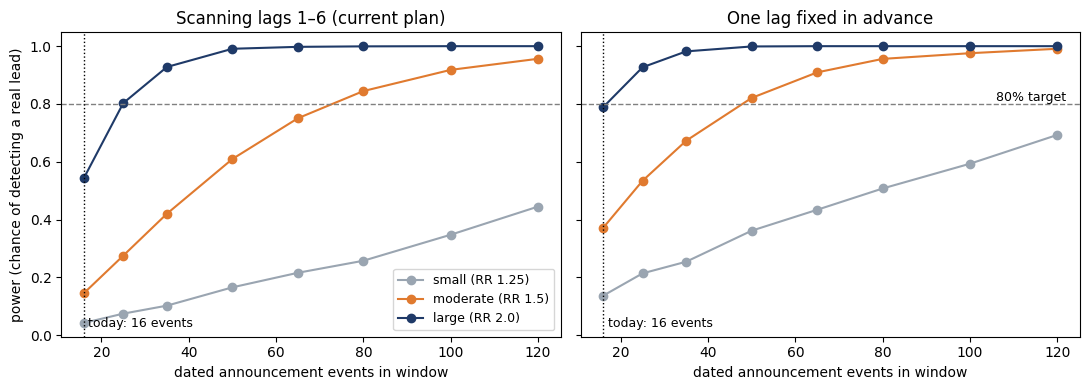

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
colors = {1.25: "#9aa5b1", 1.5: "#e07a2f", 2.0: "#1f3a68"}
labels = {1.25: "small (RR 1.25)", 1.5: "moderate (RR 1.5)", 2.0: "large (RR 2.0)"}
for ax, col, title in [(axes[0], "power_lag_scan", "Scanning lags 1–6"),
                       (axes[1], "power_lag_known", "One lag fixed in advance")]:
    for rr in [1.25, 1.5, 2.0]:
        d = grid[grid["RR"] == rr]
        ax.plot(d["events"], d[col], marker="o", color=colors[rr], label=labels[rr])
    ax.axhline(0.8, ls="--", color="grey", lw=1)
    ax.axvline(16, ls=":", color="black", lw=1)
    ax.text(17, 0.03, "today: 16 events", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("dated announcement events in window")
axes[0].set_ylabel("power")
axes[0].legend(loc="lower right", fontsize=9)
axes[1].text(122, 0.81, "80% target", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

## 5. How many events for 80% power?

In [ ]:
def events_needed(col, rr=1.5, target=0.8):
    d = grid[grid["RR"] == rr].sort_values("events")
    return int(round(np.interp(target, d[col], d["events"])))

print("lag scan :", events_needed("power_lag_scan"), "events")
print("lag known:", events_needed("power_lag_known"), "events")

lag scan : 73 events
lag known: 48 events


## 6. Does a longer window help?

The registration series goes back to 2018. I use it to compare a longer time window with the current production window, keeping the event count the same.

In [ ]:
short = simulate_power(x_prod, 41, 1.5)
long_ = simulate_power(x_reg, 41, 1.5)
print(f"41 events, RR 1.5 — 39-month production window : lag scan {short[1]:.2f}, lag known {short[0]:.2f}")
print(f"41 events, RR 1.5 — {len(x_reg)}-month registration window: lag scan {long_[1]:.2f}, lag known {long_[0]:.2f}")

41 events, RR 1.5 — 39-month production window : lag scan 0.49, lag known 0.73
41 events, RR 1.5 — 103-month registration window: lag scan 0.69, lag known 0.84


## 7. Real data

Here I run the same regression on the 16 real events. This is mainly a reference point rather than a final conclusion.

In [ ]:
months = growth.index
Y = counts.reindex(months, fill_value=0).values
out = []
for k in LAGS:
    Xd, r = design(x_prod, k, len(x_prod))
    m = sm.GLM(Y[r], Xd, family=sm.families.Poisson()).fit()
    out.append({"lag_k": k, "rate_ratio": np.exp(m.params[2]), "p_value": m.pvalues[2], "events_used": int(Y[r].sum())})
pd.DataFrame(out).round(3)

,lag_k,rate_ratio,p_value,events_used
0,1,1.068,0.809,16
1,2,1.028,0.916,16
2,3,0.614,0.117,15
3,4,1.513,0.106,15
4,5,0.935,0.797,15
5,6,1.186,0.490,15


## Summary

- With only 16 dated events, the test has low power. With the six-lag scan, a moderate effect is detected only about 15% of the time, while a large effect is detected about half the time.
- For a moderate effect and 80% power, the simulation needs roughly 75 events when scanning six lags. If the lag is fixed in advance, it takes about 45.
- Using a longer time window helps, but the event data also need to cover that earlier period.
- The real-data results do not show a clear lead. Given the low power, this does not provide strong evidence that there is no lead.